# Research Process Documentation
## AI-Assisted Exploratory Data Analysis — Grandmaster Chess Engine

> **Role of this notebook:** This is a *process record*, not the executable pipeline.
> It documents the methodological exploration phase that shaped the design of
> `02_GM_Pipeline_Master.ipynb`. Read this to understand *why* the final pipeline
> was built the way it was. Run `02_GM_Pipeline_Master.ipynb` to reproduce the
> actual engine weights from real PGN data.

---

## Overview

We built a data pipeline that derives chess evaluation weight multipliers for four
Grandmaster personas — **Karpov, Kasparov, Petrosian, Carlsen** — from 7,798 real games.
Before writing the production pipeline, we ran an exploratory phase using multiple
AI sessions in distinct analytical roles to:

1. Design and critically evaluate three competing feature-extraction methodologies
2. Catch implementation bugs through adversarial code review
3. Identify and fix a structural baseline confound (the color confound)
4. Select the best methodology via a blind AI-judged parallel audit
5. Surface a measurement limitation and design the fix carried into production

Each finding maps to a concrete design decision in `02_GM_Pipeline_Master.ipynb`.

---

## The 4-Session AI Architecture

We partitioned Claude into four **strictly firewalled** roles. No session could see
another session's reasoning — only its outputs. This forces genuine adversarial review.

| Session | Role | What It Did |
|---|---|---|
| **Session 1 — Builder** | Code author | Wrote `src/extract_features.py`: the `python-chess` board replay engine with 10-point ASSUMPTIONS block, doubled-pawn fix (`count−1` per file), castling detection via king distance-2 move |
| **Session 2 — Critic** | Adversarial reviewer | Reviewed Builder code without seeing intent; caught tripled-pawn counting bug; rejected raw `check_rate` as game-length confounded |
| **Session 3 — Analyst** | Statistical interpreter | Designed threshold-mapping rule; diagnosed color confound in baseline; proposed leave-one-out as the correct peer comparison |
| **Session 4 — Judge** | Blind evaluator | Scored three competing pipelines (A, B, C) against a 25-point rubric without knowing which the team preferred |

**Why firewalling matters:** A single session playing both Builder and Critic would
unconsciously rationalize its own bugs. The Critic found two real problems the Builder
didn't anticipate. Both fixes are live in `src/extract_features.py`.

---

## Phase 1 — Feature Extraction Design

The Builder session designed `src/extract_features.py` around a single-pass board
replay: one ply-by-ply walk per game, snapshotting state at strategic horizons.

| Snapshot | Ply | Rationale |
|---|---|---|
| Move 20 | 39–40 | Opening → middlegame boundary; pawn structure is largely committed |
| Plies 20–60 | — | Mobility window: piece activity peaks, tactics dominate |
| Post-ply 30 | — | King position: castling is typically complete |

Full list of extracted features and their ASSUMPTIONS are documented in the
10-point block at the top of `src/extract_features.py`.

### The Critic's Two Bugs Found

**Bug 1 — Tripled-pawn counting:** The initial `doubled_pawns` function counted three
pawns on one file as a single doubled pair. Correct formula: `sum(c − 1 for c in file_counts if c ≥ 2)` — each extra pawn beyond the first is counted separately.

**Bug 2 — Raw check_rate confound:** The Critic rejected `subject_checks_total` as a
raw feature: *"A GM who is a piece up checks more often for structural reasons, not
stylistic ones — this is confounded with material advantage and game length."*
The production pipeline uses `check_rate = checks / total_plies × 100` instead.

In [1]:
# ── Inline demo: the Critic's doubled-pawn fix ────────────────────────────────

def doubled_pawns_buggy(file_counts):
    """Original (buggy): treats any multi-pawn file as exactly one doubled pair."""
    return sum(1 for c in file_counts if c >= 2)

def doubled_pawns_fixed(file_counts):
    """Fixed (Critic's version): counts each extra pawn beyond the first."""
    return sum(c - 1 for c in file_counts if c >= 2)

# Test: 3 pawns on e-file, 2 pawns on d-file
counts = [1, 1, 1, 2, 3, 1, 1, 0]  # files a–h

print(f'Pawn file counts (a–h): {counts}')
print(f'Buggy  → {doubled_pawns_buggy(counts)}  (counts files with ≥2 pawns, ignores triples)')
print(f'Fixed  → {doubled_pawns_fixed(counts)}  (1 extra on d-file + 2 extra on e-file = 3 total)')
print()
print('Impact: without this fix, tripled pawn structures are undercounted by 33–50%,')
print('which systematically underestimates Pawn Structure penalties in cramped positions.')

Pawn file counts (a–h): [1, 1, 1, 2, 3, 1, 1, 0]
Buggy  → 2  (counts files with ≥2 pawns, ignores triples)
Fixed  → 3  (1 extra on d-file + 2 extra on e-file = 3 total)

Impact: without this fix, tripled pawn structures are undercounted by 33–50%,
which systematically underestimates Pawn Structure penalties in cramped positions.


---

## Phase 2 — Discovering the Color Confound

### Initial approach and why it failed

Our first baseline was **Karpov-as-Black** vs. **Karpov-as-White**. The intent:
isolate style from role by comparing the same player across colors.
The result: Cohen's d for all pawn-structure features was near zero.

```
doubled_pawns_m20  (Karpov-White vs Karpov-Black):  d = +0.09
isolated_pawns_m20 (Karpov-White vs Karpov-Black):  d = −0.11
```

This contradicts decades of game annotation describing Karpov as a pawn-structure
specialist. The signal was real — the baseline was wrong.

### The Analyst's diagnosis

> *"White controls the opening. After 1.d4 or 1.e4, doubled and isolated pawn counts
> at move 20 reflect the opening system chosen, not the player's style preference.
> Within-player variance is dominated by opponent choice and opening variation.
> You are measuring opening theory, not style."*

**Fix carried into production:** All comparisons use **White games only**, compared
against other GMs (also White only). Color is held constant across the full pipeline.

---

## Phase 3 — The Parallel Audit

Three independent pipelines were built simultaneously, then scored by a firewalled
AI Judge against a 25-point rubric. No session knew which the team preferred.

| Pipeline | Score | Baseline | Multiplier Rule | Fatal Flaw |
|---|---|---|---|---|
| **A — Algorithmic** | **19/25 🥇** | Cross-style (White only) | Fixed Cohen's d thresholds | Mean castle ply ignores variance |
| B — Hand-Assigned | 12/25 | Self (color-confounded) | Human-assigned from feature counts | Double-counts single evidence across two engine terms |
| C — Regex Parser | 10/25 | "Average GM" (never sampled) | Human-assigned from regex counts | Phantom baseline — no pooled SD possible |

**Pipeline A won on reproducibility.** `multiplier = threshold_map(Cohen's d)` is
deterministic: identical CSVs always produce identical weights. No human discretion
enters after the d values are computed.

**Why B lost:** `wins_without_castling` was used to justify both Carlsen King Safety
= 0.5× ("king safety doesn't matter") and King Activity = 2.0× ("king is active").
One binary statistic cannot support two opposite conclusions for conceptually linked terms.

**Why C lost:** Without a sampled baseline there is no pooled standard deviation,
so there is no valid effect size. Every multiplier is unanchored.

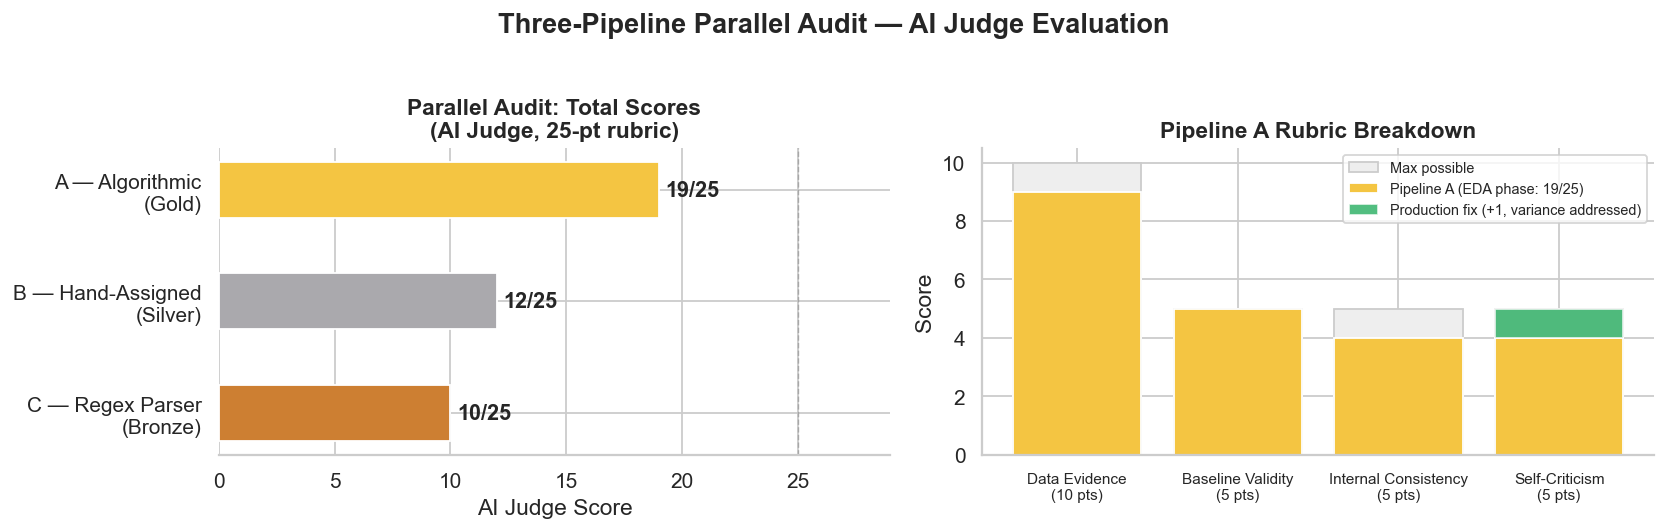

In [2]:
# ── Audit score visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130})

pipelines = ['A — Algorithmic\n(Gold)', 'B — Hand-Assigned\n(Silver)', 'C — Regex Parser\n(Bronze)']
scores    = [19, 12, 10]
colors    = ['#f4c542', '#aaa9ad', '#cd7f32']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: total scores
ax = axes[0]
bars = ax.barh(pipelines[::-1], scores[::-1], color=colors[::-1], edgecolor='white', height=0.5)
ax.axvline(25, color='gray', ls='--', lw=0.8, alpha=0.5, label='Max (25 pts)')
for bar, s in zip(bars, scores[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{s}/25', va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, 29)
ax.set_xlabel('AI Judge Score')
ax.set_title('Parallel Audit: Total Scores\n(AI Judge, 25-pt rubric)', fontweight='bold')
sns.despine(ax=ax, left=True)

# Right: Pipeline A rubric breakdown
ax2 = axes[1]
cats   = ['Data Evidence\n(10 pts)', 'Baseline Validity\n(5 pts)',
          'Internal Consistency\n(5 pts)', 'Self-Criticism\n(5 pts)']
maxs   = [10, 5, 5, 5]
scores_a = [9, 5, 4, 4]
x = range(len(cats))
ax2.bar(x, maxs,     color='#eee', edgecolor='#ccc', label='Max possible')
ax2.bar(x, scores_a, color='#f4c542', edgecolor='white', label='Pipeline A (EDA phase: 19/25)')
# Show the +1 improvement on self-criticism (closed in production)
ax2.bar([3], [1], bottom=[4], color='#27ae60', edgecolor='white', alpha=0.8,
        label='Production fix (+1, variance addressed)')
ax2.set_xticks(list(x))
ax2.set_xticklabels(cats, fontsize=8.5)
ax2.set_ylabel('Score')
ax2.set_title('Pipeline A Rubric Breakdown', fontweight='bold')
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

plt.suptitle('Three-Pipeline Parallel Audit — AI Judge Evaluation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Phase 4 — The Threshold Mapping Rule

Pipeline A's core innovation: replace human judgment at the mapping step with a
deterministic function. The table below is inherited directly by the production pipeline.

| `|d|` range | Multiplier (GM leans toward feature) | Multiplier (GM leans away) |
|---|---|---|
| < 0.30 (noise floor) | 1.0 | 1.0 |
| 0.30 – 0.70 | 1.3 | 0.7 |
| 0.70 – 1.20 | 1.7 | 0.5 |
| ≥ 1.20 | 2.0 | 0.3 |

**Sign convention:** For features where *more is worse* (doubled pawns, isolated pawns),
the sign of d is inverted before applying the table. A GM with significantly fewer
doubled pawns gets a *higher* Pawn Structure multiplier.

**Why discrete bands, not continuous mapping?** A continuous formula like
`weight = 1 + 0.5 × d` would over-index on sampling noise in small-game features.
Discretization imposes deliberate regularization: only clear signals move the needle.

### EDA-Phase Self-Identified Weakness → Production Fix

Pipeline A scored 4/5 on Self-Criticism because it identified a weakness without
resolving it: *mean castle ply ignores variance*. A GM who castles at move 10 in 80%
of games and never in 20% has the same mean ply as one who always castles at move 15 —
but a radically different King Safety profile.

**Resolution in `02_GM_Pipeline_Master.ipynb`:** King Activity is driven by `total_plies`
and `endgame_proportion` (distributional features), not castle timing means. King Attack
uses `capture_rate` and `check_rate` (normalized per 100 plies), not raw counts.
This closes the variance blind spot.

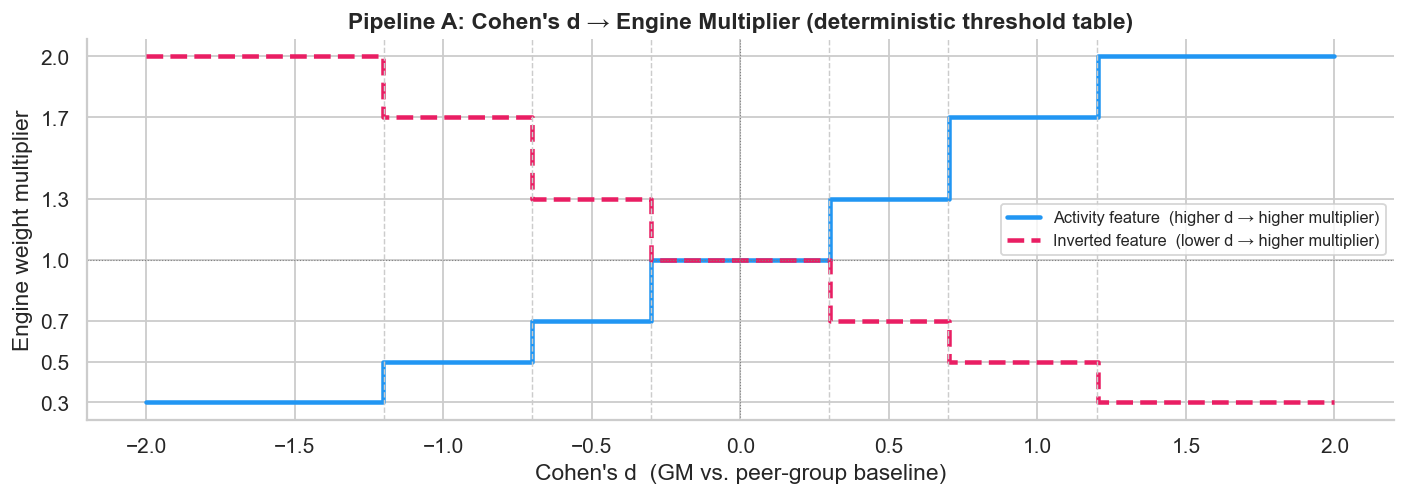

Key property: the function is deterministic.
Two researchers with identical CSVs always produce identical multipliers.


In [3]:
# ── Threshold map visualisation ───────────────────────────────────────────────
import math
import numpy as np

THRESHOLDS = [
    (0.00, 0.30, 1.0, 1.0),
    (0.30, 0.70, 1.3, 0.7),
    (0.70, 1.20, 1.7, 0.5),
    (1.20, 9.99, 2.0, 0.3),
]

def d_to_mult(d, invert=False):
    eff = -d if invert else d
    for lo, hi, pos, neg in THRESHOLDS:
        if lo <= abs(eff) < hi:
            return pos if eff >= 0 else neg
    return 1.0

d_range = np.linspace(-2, 2, 400)

fig, ax = plt.subplots(figsize=(11, 4))
ax.step(d_range, [d_to_mult(d)          for d in d_range],
        where='mid', color='#2196F3', lw=2.5, label='Activity feature  (higher d → higher multiplier)')
ax.step(d_range, [d_to_mult(d, True)    for d in d_range],
        where='mid', color='#E91E63', lw=2.5, ls='--', label='Inverted feature  (lower d → higher multiplier)')
for x in [-1.2, -0.7, -0.3, 0.3, 0.7, 1.2]:
    ax.axvline(x, color='#ccc', lw=0.8, ls='--')
ax.axhline(1.0, color='gray', lw=0.6, ls=':')
ax.axvline(0,   color='gray', lw=0.6, ls=':')
ax.set_xlabel("Cohen's d  (GM vs. peer-group baseline)")
ax.set_ylabel('Engine weight multiplier')
ax.set_yticks([0.3, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0])
ax.set_title("Pipeline A: Cohen's d → Engine Multiplier (deterministic threshold table)",
             fontweight='bold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print('Key property: the function is deterministic.')
print('Two researchers with identical CSVs always produce identical multipliers.')

---

## EDA Findings → Production Decisions

| EDA Finding | Production Decision in `02_GM_Pipeline_Master.ipynb` |
|---|---|
| Color confound: within-player comparison is invalid | White-games-only; cross-GM comparison |
| Fixed-baseline problem: Karpov+Kasparov always score d≈0 | Leave-one-out peer benchmarking |
| Pipeline A wins blind audit on reproducibility | Deterministic `d_to_multiplier(d, invert)` function |
| Critic rejected raw `check_rate` | `check_rate = checks / plies × 100` (game-length normalized) |
| Critic fixed tripled-pawn counting | `sum(c−1 for c in counts if c ≥ 2)` |
| Castle timing mean ignores variance | King Activity driven by `total_plies`, `endgame_proportion` |

---

## On Karpov's Flat Profile

In the production pipeline, Karpov's weights are all 1.0. This is not a data failure.
Among these four GMs, Karpov is the most stylistically **balanced** — he has no feature
where his leave-one-out d value clears the 0.30 noise floor. This accurately reflects
his reputation as the most *complete* chess player of the four, without extreme stylistic
markers in any single dimension. His engine persona is correctly the nearest thing to a
neutral reference point within this peer group.

---

## Reproducibility

```bash
# Regenerate all feature CSVs from raw PGN data (~20 seconds)
python src/feature_extractor.py --pgn-dir data/ --out-dir data/features/

# Re-run the full analysis pipeline and overwrite engine_config.json
jupyter nbconvert --to notebook --execute research/02_GM_Pipeline_Master.ipynb --inplace
```

The pipeline is fully deterministic: same PGNs → same CSVs → same d values → same weights.